### EDA

In [8]:
#### Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

#### Data path
data_path = os.path.join(
    'Data',
    'clean_splac.csv'
)

#### Reading data
##### Reading data
df = pd.read_csv(
    data_path,
    parse_dates=['Date'],
    index_col='Date'
)

In [2]:
#### Overview summary
df_stats = df.describe().round(3)
df_stats.loc['current'] = df.iloc[-1].round(3)
df_stats.loc[['current','mean','std']].T.sort_values(by='current', ascending=False)

,current,mean,std
ISA.CL,30000.000,9467.484,5888.133
FALABELLA.SN,5875.000,3251.896,1261.634
CENCOSUD.SN,2180.000,1272.286,539.364
BAP,341.500,95.516,58.260
PAC,238.110,69.861,62.170
AC.MX,222.325,77.584,51.358
GMEXICOB.MX,213.608,42.802,37.581
FEMSAUBD.MX,206.338,100.918,50.206
SCCO,194.880,35.532,33.387
GFNORTEO.MX,185.150,60.613,40.637


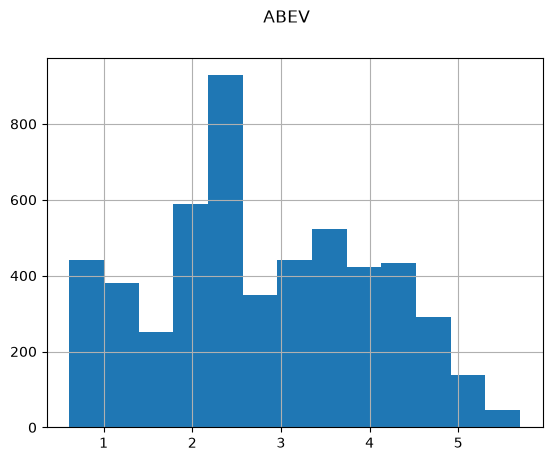

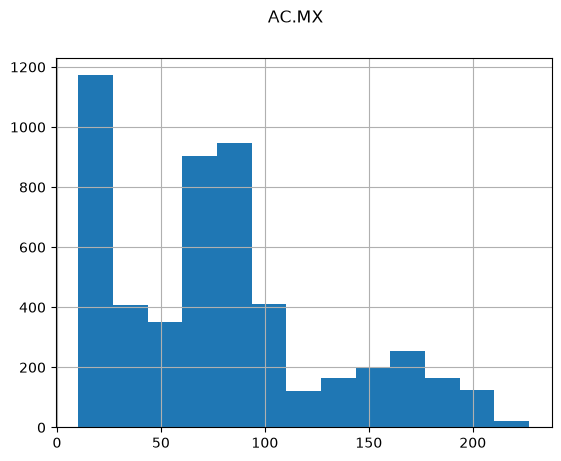

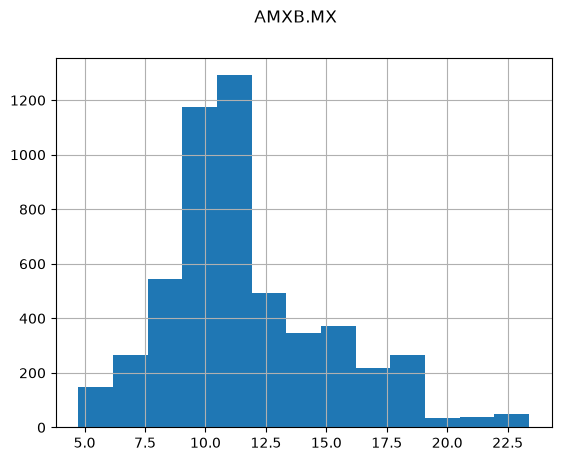

In [3]:
#### Histograms
num_bins = int(1 + (np.log(df.shape[0])/np.log(2)))
    #Sturges law
for i, col in enumerate(df.columns):
    df[col].hist(bins=num_bins)
    plt.suptitle(col)
    plt.show()
    if i == 2: break


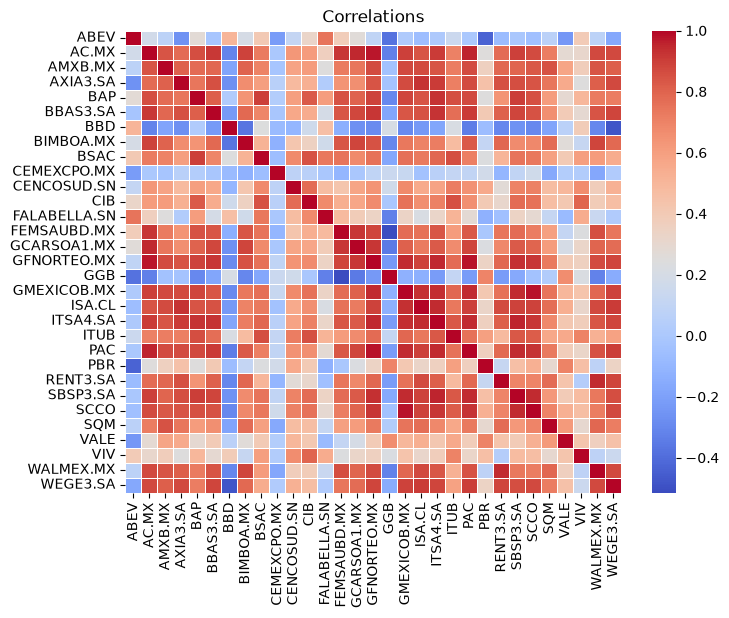

In [4]:
#### Correlation
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlations')
plt.show()

,ABEV,AC.MX,AMXB.MX,AXIA3.SA,BAP,BBAS3.SA,BBD,BIMBOA.MX,BSAC,CEMEXCPO.MX,...,PAC,PBR,RENT3.SA,SBSP3.SA,SCCO,SQM,VALE,VIV,WALMEX.MX,WEGE3.SA
ABEV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AC.MX,NaN,1.0,1.0,NaN,1.0,1.0,NaN,1.0,NaN,NaN,...,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0
AMXB.MX,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,1.0,1.0
AXIA3.SA,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0
BAP,NaN,1.0,NaN,NaN,1.0,1.0,NaN,NaN,1.0,NaN,...,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
BBAS3.SA,NaN,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0
BBD,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIMBOA.MX,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
BSAC,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CEMEXCPO.MX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ITSA4.SA        18.0
GFNORTEO.MX     17.0
PAC             17.0
BBAS3.SA        16.0
AC.MX           16.0
ISA.CL          15.0
BAP             15.0
SBSP3.SA        14.0
SCCO            14.0
WEGE3.SA        14.0
GMEXICOB.MX     14.0
AXIA3.SA        13.0
WALMEX.MX       13.0
AMXB.MX         12.0
GCARSOA1.MX     11.0
FEMSAUBD.MX     10.0
RENT3.SA         7.0
ITUB             7.0
BIMBOA.MX        7.0
BSAC             4.0
CIB              4.0
SQM              2.0
ABEV             1.0
FALABELLA.SN     1.0
CENCOSUD.SN      1.0
CEMEXCPO.MX      1.0
BBD              1.0
PBR              1.0
GGB              1.0
VIV              1.0
VALE             1.0
dtype: float64

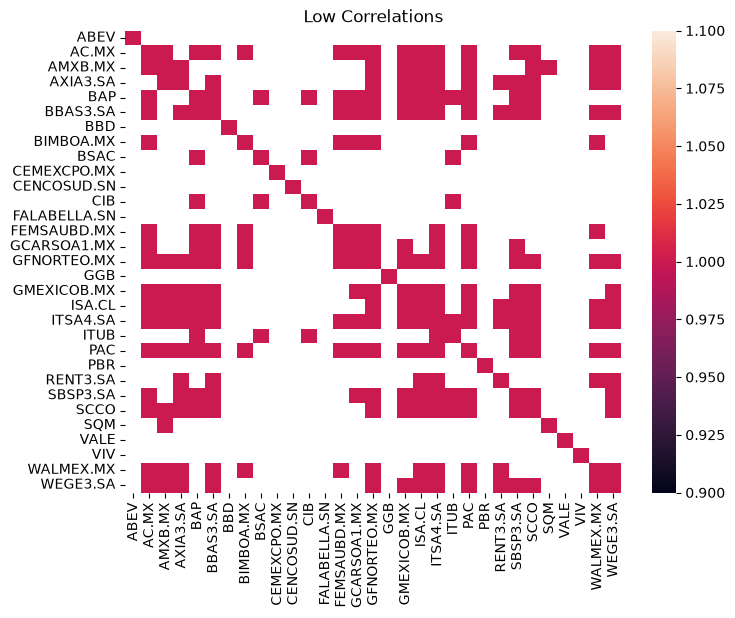

In [13]:
#### Identifying low correlations (|corr| < 0.3)
THRESH = 0.8
df_corr = df.corr()
df_corr[((df_corr < THRESH) & (df_corr > -THRESH))] = np.nan
# df_corr[~((df_corr < THRESH) & (df_corr > -THRESH))] = 1
df_corr[df_corr.notna()] = 1
display(df_corr)
display(df_corr.sum().sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(df_corr)
plt.title('Low Correlations')
plt.show()

,ABEV,AC.MX,AMXB.MX,AXIA3.SA,BAP,BBAS3.SA,BBD,BIMBOA.MX,BSAC,CEMEXCPO.MX,...,PAC,PBR,RENT3.SA,SBSP3.SA,SCCO,SQM,VALE,VIV,WALMEX.MX,WEGE3.SA
ABEV,0.000000,0.827356,0.924386,1.265076,0.725611,1.022265,0.495590,0.798842,0.595752,1.220862,...,1.000325,1.434703,1.072659,1.009016,1.051468,0.929319,1.236746,0.608626,0.928471,1.170258
AC.MX,0.827356,0.000000,0.157028,0.221802,0.136921,0.086967,1.316264,0.109957,0.272351,1.001063,...,0.043309,0.748012,0.229213,0.101095,0.133660,0.280571,0.713455,0.688257,0.124212,0.126387
AMXB.MX,0.924386,0.157028,0.000000,0.193080,0.222937,0.210224,1.185898,0.200104,0.296762,1.019412,...,0.133285,0.642169,0.212099,0.204299,0.167804,0.152170,0.421781,0.625668,0.155318,0.184911
AXIA3.SA,1.265076,0.221802,0.193080,0.000000,0.258364,0.146820,1.266503,0.335274,0.397626,0.941953,...,0.133813,0.552478,0.146148,0.139730,0.159030,0.257427,0.444822,0.755862,0.184243,0.126439
BAP,0.725611,0.136921,0.222937,0.258364,0.000000,0.184028,0.978827,0.356181,0.102048,0.968619,...,0.126063,0.755191,0.356411,0.096003,0.143831,0.386700,0.705741,0.498582,0.275119,0.280157
BBAS3.SA,1.022265,0.086967,0.210224,0.146820,0.184028,0.000000,1.228060,0.213861,0.310321,1.016753,...,0.091419,0.592965,0.192302,0.112371,0.152373,0.340995,0.605601,0.707133,0.154141,0.116352
BBD,0.495590,1.316264,1.185898,1.266503,0.978827,1.228060,0.000000,1.367502,0.758086,1.077059,...,1.341075,1.068578,1.302192,1.260612,1.299550,1.182818,0.933580,0.611377,1.303869,1.479829
BIMBOA.MX,0.798842,0.109957,0.200104,0.335274,0.356181,0.213861,1.367502,0.000000,0.481142,1.125594,...,0.174793,0.889751,0.207976,0.325327,0.314008,0.226449,0.734160,0.877179,0.117806,0.214932
BSAC,0.595752,0.272351,0.296762,0.397626,0.102048,0.310321,0.758086,0.481142,0.000000,1.061141,...,0.287571,0.767098,0.492186,0.253975,0.265947,0.404904,0.602008,0.400239,0.385671,0.453713
CEMEXCPO.MX,1.220862,1.001063,1.019412,0.941953,0.968619,1.016753,1.077059,1.125594,1.061141,0.000000,...,0.898995,0.825338,1.102839,0.903112,0.829343,1.163882,0.965541,0.975297,1.172318,0.978450


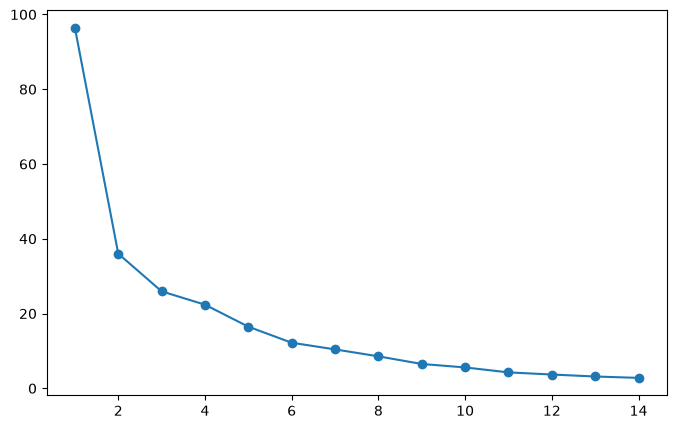

In [ ]:
#### USing KMeans - Finding optimal num clusters
### Transforming Correlation to distance
df_corr_dist = 1 - df.corr()

### Getting inertias
intertias = []
for k in range(1,15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_corr_dist)
    intertias.append(kmeans.inertia_)

### Grafig inertias
fig = plt.figure(figsize=(8,5))
plt.plot(
    range(1,15),
    intertias,
    marker='o'
)
plt.show()

# Is it good idea to only use actions that are not correlated at all (absolute correlation value < 0.3)?
